評価件数: 4000件
MAE: 0.19063 eV


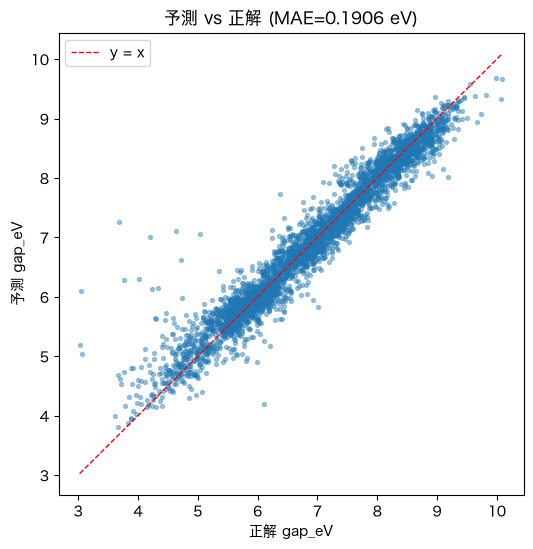

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 日本語ラベルが文字化けしないようフォントを設定
# 環境に応じて存在するフォント名に変更してください
# Windows: "MS Gothic" / "Meiryo"、Mac: "Hiragino Sans"、Linux: "IPAexGothic" や "Noto Sans CJK JP"
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False # マイナス記号の文字化け対策

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("submission_strategy1.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# 重複チェック
dup_sub = sub["smiles"].duplicated().sum()
dup_ans = ans["smiles"].duplicated().sum()
if dup_sub > 0:
    print(f"警告: submissionに重複smiles {dup_sub}件")
if dup_ans > 0:
    print(f"警告: 正解ファイルに重複smiles {dup_ans}件")

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# 欠損行は評価から除外(欠損があるとmean_absolute_errorがエラーになるため)
eval_df = merged.dropna(subset=["gap_eV_true", "gap_eV_pred"]).copy()

# MAE計算
mae = mean_absolute_error(eval_df["gap_eV_true"], eval_df["gap_eV_pred"])
print(f"評価件数: {len(eval_df)}件")
print(f"MAE: {mae:.5f} eV")

# 誤差列を追加
eval_df["error"] = eval_df["gap_eV_pred"] - eval_df["gap_eV_true"]

# --- 可視化 ---
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# 1. 予測 vs 正解の散布図(y=xに近いほど良い)
axes.scatter(eval_df["gap_eV_true"], eval_df["gap_eV_pred"], s=8, alpha=0.4)
lims = [
    min(eval_df["gap_eV_true"].min(), eval_df["gap_eV_pred"].min()),
    max(eval_df["gap_eV_true"].max(), eval_df["gap_eV_pred"].max()),
]
axes.plot(lims, lims, "r--", linewidth=1, label="y = x")
axes.set_xlabel("正解 gap_eV")
axes.set_ylabel("予測 gap_eV")
axes.set_title(f"予測 vs 正解 (MAE={mae:.4f} eV)")
axes.legend()

評価件数: 4000件
MAE: 0.20447 eV


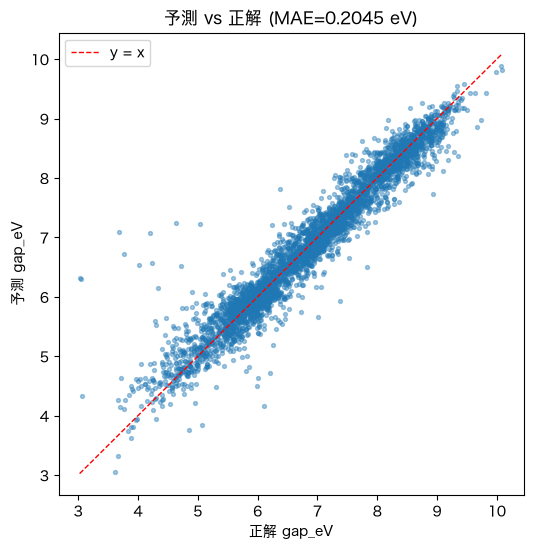

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 日本語ラベルが文字化けしないようフォントを設定
# 環境に応じて存在するフォント名に変更してください
# Windows: "MS Gothic" / "Meiryo"、Mac: "Hiragino Sans"、Linux: "IPAexGothic" や "Noto Sans CJK JP"
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False # マイナス記号の文字化け対策

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("submission_strategy2.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# 重複チェック
dup_sub = sub["smiles"].duplicated().sum()
dup_ans = ans["smiles"].duplicated().sum()
if dup_sub > 0:
    print(f"警告: submissionに重複smiles {dup_sub}件")
if dup_ans > 0:
    print(f"警告: 正解ファイルに重複smiles {dup_ans}件")

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# 欠損行は評価から除外(欠損があるとmean_absolute_errorがエラーになるため)
eval_df = merged.dropna(subset=["gap_eV_true", "gap_eV_pred"]).copy()

# MAE計算
mae = mean_absolute_error(eval_df["gap_eV_true"], eval_df["gap_eV_pred"])
print(f"評価件数: {len(eval_df)}件")
print(f"MAE: {mae:.5f} eV")

# 誤差列を追加
eval_df["error"] = eval_df["gap_eV_pred"] - eval_df["gap_eV_true"]

# --- 可視化 ---
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# 1. 予測 vs 正解の散布図(y=xに近いほど良い)
axes.scatter(eval_df["gap_eV_true"], eval_df["gap_eV_pred"], s=8, alpha=0.4)
lims = [
    min(eval_df["gap_eV_true"].min(), eval_df["gap_eV_pred"].min()),
    max(eval_df["gap_eV_true"].max(), eval_df["gap_eV_pred"].max()),
]
axes.plot(lims, lims, "r--", linewidth=1, label="y = x")
axes.set_xlabel("正解 gap_eV")
axes.set_ylabel("予測 gap_eV")
axes.set_title(f"予測 vs 正解 (MAE={mae:.4f} eV)")
axes.legend()

評価件数: 4000件
MAE: 0.19025 eV


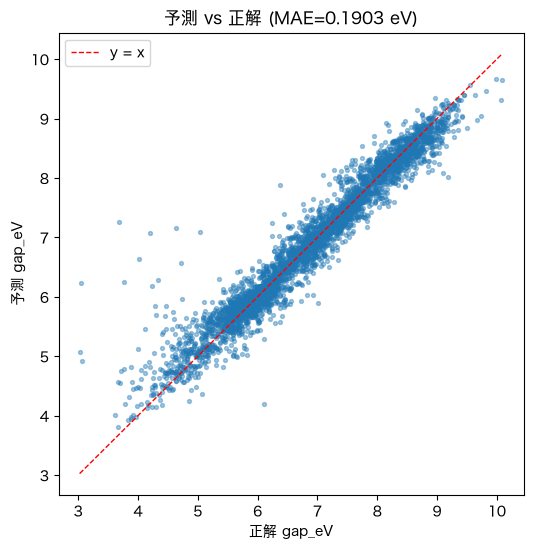

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 日本語ラベルが文字化けしないようフォントを設定
# 環境に応じて存在するフォント名に変更してください
# Windows: "MS Gothic" / "Meiryo"、Mac: "Hiragino Sans"、Linux: "IPAexGothic" や "Noto Sans CJK JP"
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False # マイナス記号の文字化け対策

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("submission_strategy3.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# 重複チェック
dup_sub = sub["smiles"].duplicated().sum()
dup_ans = ans["smiles"].duplicated().sum()
if dup_sub > 0:
    print(f"警告: submissionに重複smiles {dup_sub}件")
if dup_ans > 0:
    print(f"警告: 正解ファイルに重複smiles {dup_ans}件")

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# 欠損行は評価から除外(欠損があるとmean_absolute_errorがエラーになるため)
eval_df = merged.dropna(subset=["gap_eV_true", "gap_eV_pred"]).copy()

# MAE計算
mae = mean_absolute_error(eval_df["gap_eV_true"], eval_df["gap_eV_pred"])
print(f"評価件数: {len(eval_df)}件")
print(f"MAE: {mae:.5f} eV")

# 誤差列を追加
eval_df["error"] = eval_df["gap_eV_pred"] - eval_df["gap_eV_true"]

# --- 可視化 ---
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# 1. 予測 vs 正解の散布図(y=xに近いほど良い)
axes.scatter(eval_df["gap_eV_true"], eval_df["gap_eV_pred"], s=8, alpha=0.4)
lims = [
    min(eval_df["gap_eV_true"].min(), eval_df["gap_eV_pred"].min()),
    max(eval_df["gap_eV_true"].max(), eval_df["gap_eV_pred"].max()),
]
axes.plot(lims, lims, "r--", linewidth=1, label="y = x")
axes.set_xlabel("正解 gap_eV")
axes.set_ylabel("予測 gap_eV")
axes.set_title(f"予測 vs 正解 (MAE={mae:.4f} eV)")
axes.legend()

評価件数: 4000件
MAE: 0.20350 eV


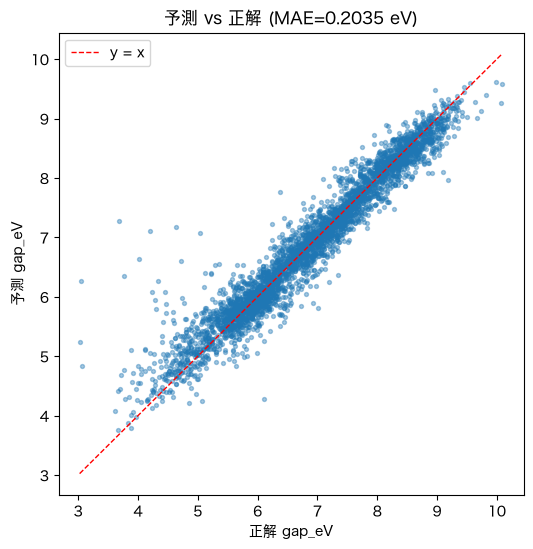

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 日本語ラベルが文字化けしないようフォントを設定
# 環境に応じて存在するフォント名に変更してください
# Windows: "MS Gothic" / "Meiryo"、Mac: "Hiragino Sans"、Linux: "IPAexGothic" や "Noto Sans CJK JP"
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False # マイナス記号の文字化け対策

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("submission_1_descriptors_lgbm.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# 重複チェック
dup_sub = sub["smiles"].duplicated().sum()
dup_ans = ans["smiles"].duplicated().sum()
if dup_sub > 0:
    print(f"警告: submissionに重複smiles {dup_sub}件")
if dup_ans > 0:
    print(f"警告: 正解ファイルに重複smiles {dup_ans}件")

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# 欠損行は評価から除外(欠損があるとmean_absolute_errorがエラーになるため)
eval_df = merged.dropna(subset=["gap_eV_true", "gap_eV_pred"]).copy()

# MAE計算
mae = mean_absolute_error(eval_df["gap_eV_true"], eval_df["gap_eV_pred"])
print(f"評価件数: {len(eval_df)}件")
print(f"MAE: {mae:.5f} eV")

# 誤差列を追加
eval_df["error"] = eval_df["gap_eV_pred"] - eval_df["gap_eV_true"]

# --- 可視化 ---
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# 1. 予測 vs 正解の散布図(y=xに近いほど良い)
axes.scatter(eval_df["gap_eV_true"], eval_df["gap_eV_pred"], s=8, alpha=0.4)
lims = [
    min(eval_df["gap_eV_true"].min(), eval_df["gap_eV_pred"].min()),
    max(eval_df["gap_eV_true"].max(), eval_df["gap_eV_pred"].max()),
]
axes.plot(lims, lims, "r--", linewidth=1, label="y = x")
axes.set_xlabel("正解 gap_eV")
axes.set_ylabel("予測 gap_eV")
axes.set_title(f"予測 vs 正解 (MAE={mae:.4f} eV)")
axes.legend()

評価件数: 4000件
MAE: 0.19371 eV


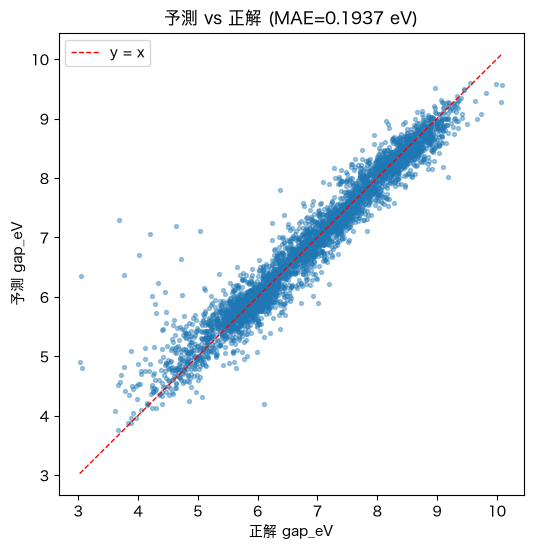

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 日本語ラベルが文字化けしないようフォントを設定
# 環境に応じて存在するフォント名に変更してください
# Windows: "MS Gothic" / "Meiryo"、Mac: "Hiragino Sans"、Linux: "IPAexGothic" や "Noto Sans CJK JP"
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False # マイナス記号の文字化け対策

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("submission_2_descriptors_morgan_lgbm.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# 重複チェック
dup_sub = sub["smiles"].duplicated().sum()
dup_ans = ans["smiles"].duplicated().sum()
if dup_sub > 0:
    print(f"警告: submissionに重複smiles {dup_sub}件")
if dup_ans > 0:
    print(f"警告: 正解ファイルに重複smiles {dup_ans}件")

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# 欠損行は評価から除外(欠損があるとmean_absolute_errorがエラーになるため)
eval_df = merged.dropna(subset=["gap_eV_true", "gap_eV_pred"]).copy()

# MAE計算
mae = mean_absolute_error(eval_df["gap_eV_true"], eval_df["gap_eV_pred"])
print(f"評価件数: {len(eval_df)}件")
print(f"MAE: {mae:.5f} eV")

# 誤差列を追加
eval_df["error"] = eval_df["gap_eV_pred"] - eval_df["gap_eV_true"]

# --- 可視化 ---
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# 1. 予測 vs 正解の散布図(y=xに近いほど良い)
axes.scatter(eval_df["gap_eV_true"], eval_df["gap_eV_pred"], s=8, alpha=0.4)
lims = [
    min(eval_df["gap_eV_true"].min(), eval_df["gap_eV_pred"].min()),
    max(eval_df["gap_eV_true"].max(), eval_df["gap_eV_pred"].max()),
]
axes.plot(lims, lims, "r--", linewidth=1, label="y = x")
axes.set_xlabel("正解 gap_eV")
axes.set_ylabel("予測 gap_eV")
axes.set_title(f"予測 vs 正解 (MAE={mae:.4f} eV)")
axes.legend()

評価件数: 4000件
MAE: 0.19395 eV


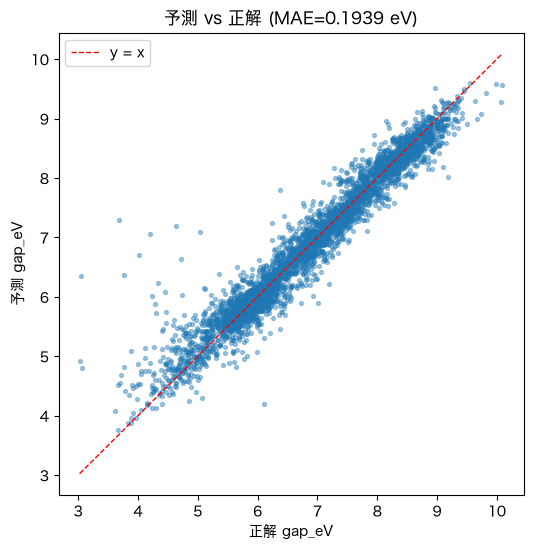

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 日本語ラベルが文字化けしないようフォントを設定
# 環境に応じて存在するフォント名に変更してください
# Windows: "MS Gothic" / "Meiryo"、Mac: "Hiragino Sans"、Linux: "IPAexGothic" や "Noto Sans CJK JP"
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False # マイナス記号の文字化け対策

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("submission_3_blend.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# 重複チェック
dup_sub = sub["smiles"].duplicated().sum()
dup_ans = ans["smiles"].duplicated().sum()
if dup_sub > 0:
    print(f"警告: submissionに重複smiles {dup_sub}件")
if dup_ans > 0:
    print(f"警告: 正解ファイルに重複smiles {dup_ans}件")

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# 欠損行は評価から除外(欠損があるとmean_absolute_errorがエラーになるため)
eval_df = merged.dropna(subset=["gap_eV_true", "gap_eV_pred"]).copy()

# MAE計算
mae = mean_absolute_error(eval_df["gap_eV_true"], eval_df["gap_eV_pred"])
print(f"評価件数: {len(eval_df)}件")
print(f"MAE: {mae:.5f} eV")

# 誤差列を追加
eval_df["error"] = eval_df["gap_eV_pred"] - eval_df["gap_eV_true"]

# --- 可視化 ---
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# 1. 予測 vs 正解の散布図(y=xに近いほど良い)
axes.scatter(eval_df["gap_eV_true"], eval_df["gap_eV_pred"], s=8, alpha=0.4)
lims = [
    min(eval_df["gap_eV_true"].min(), eval_df["gap_eV_pred"].min()),
    max(eval_df["gap_eV_true"].max(), eval_df["gap_eV_pred"].max()),
]
axes.plot(lims, lims, "r--", linewidth=1, label="y = x")
axes.set_xlabel("正解 gap_eV")
axes.set_ylabel("予測 gap_eV")
axes.set_title(f"予測 vs 正解 (MAE={mae:.4f} eV)")
axes.legend()

評価件数: 4000件
MAE: 0.18513 eV


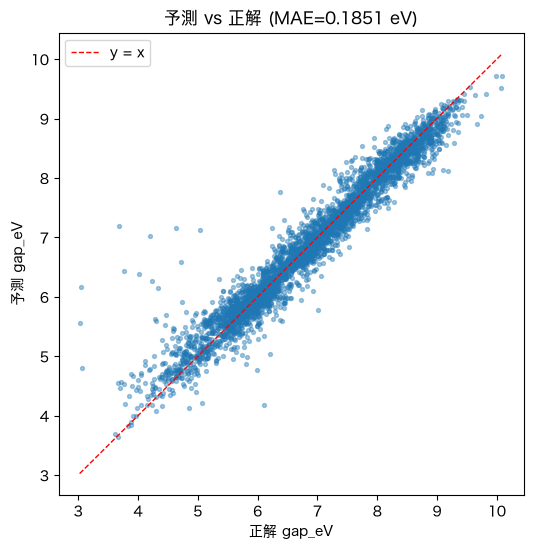

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 日本語ラベルが文字化けしないようフォントを設定
# 環境に応じて存在するフォント名に変更してください
# Windows: "MS Gothic" / "Meiryo"、Mac: "Hiragino Sans"、Linux: "IPAexGothic" や "Noto Sans CJK JP"
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False # マイナス記号の文字化け対策

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("submission_blend2_reference.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# 重複チェック
dup_sub = sub["smiles"].duplicated().sum()
dup_ans = ans["smiles"].duplicated().sum()
if dup_sub > 0:
    print(f"警告: submissionに重複smiles {dup_sub}件")
if dup_ans > 0:
    print(f"警告: 正解ファイルに重複smiles {dup_ans}件")

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# 欠損行は評価から除外(欠損があるとmean_absolute_errorがエラーになるため)
eval_df = merged.dropna(subset=["gap_eV_true", "gap_eV_pred"]).copy()

# MAE計算
mae = mean_absolute_error(eval_df["gap_eV_true"], eval_df["gap_eV_pred"])
print(f"評価件数: {len(eval_df)}件")
print(f"MAE: {mae:.5f} eV")

# 誤差列を追加
eval_df["error"] = eval_df["gap_eV_pred"] - eval_df["gap_eV_true"]

# --- 可視化 ---
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# 1. 予測 vs 正解の散布図(y=xに近いほど良い)
axes.scatter(eval_df["gap_eV_true"], eval_df["gap_eV_pred"], s=8, alpha=0.4)
lims = [
    min(eval_df["gap_eV_true"].min(), eval_df["gap_eV_pred"].min()),
    max(eval_df["gap_eV_true"].max(), eval_df["gap_eV_pred"].max()),
]
axes.plot(lims, lims, "r--", linewidth=1, label="y = x")
axes.set_xlabel("正解 gap_eV")
axes.set_ylabel("予測 gap_eV")
axes.set_title(f"予測 vs 正解 (MAE={mae:.4f} eV)")
axes.legend()

評価件数: 4000件
MAE: 0.18474 eV


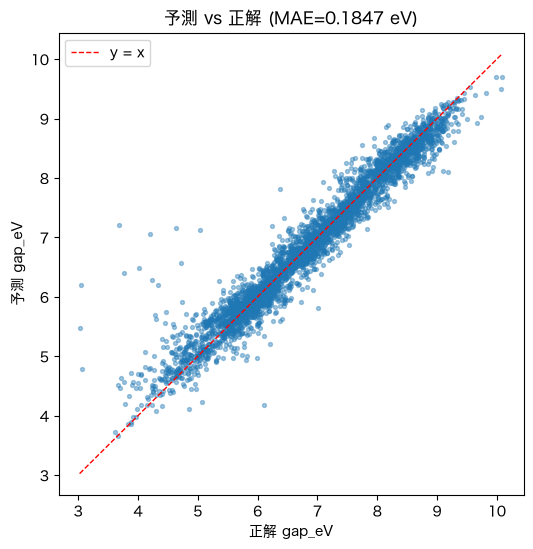

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 日本語ラベルが文字化けしないようフォントを設定
# 環境に応じて存在するフォント名に変更してください
# Windows: "MS Gothic" / "Meiryo"、Mac: "Hiragino Sans"、Linux: "IPAexGothic" や "Noto Sans CJK JP"
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False # マイナス記号の文字化け対策

# 提出ファイルと正解ファイルを読み込み
sub = pd.read_csv("submission_blend3_reference.csv")       # columns: smiles, gap_eV
ans = pd.read_csv("qm9_bandgap_test_with_answer.csv")  # columns: smiles, gap_eV

# 重複チェック
dup_sub = sub["smiles"].duplicated().sum()
dup_ans = ans["smiles"].duplicated().sum()
if dup_sub > 0:
    print(f"警告: submissionに重複smiles {dup_sub}件")
if dup_ans > 0:
    print(f"警告: 正解ファイルに重複smiles {dup_ans}件")

# smilesをキーにマージ
merged = ans.merge(sub, on="smiles", how="left", suffixes=("_true", "_pred"))

# 欠損チェック
missing = merged["gap_eV_pred"].isna().sum()
if missing > 0:
    print(f"警告: {missing}件のsmilesが提出ファイルに存在しません")

# 欠損行は評価から除外(欠損があるとmean_absolute_errorがエラーになるため)
eval_df = merged.dropna(subset=["gap_eV_true", "gap_eV_pred"]).copy()

# MAE計算
mae = mean_absolute_error(eval_df["gap_eV_true"], eval_df["gap_eV_pred"])
print(f"評価件数: {len(eval_df)}件")
print(f"MAE: {mae:.5f} eV")

# 誤差列を追加
eval_df["error"] = eval_df["gap_eV_pred"] - eval_df["gap_eV_true"]

# --- 可視化 ---
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# 1. 予測 vs 正解の散布図(y=xに近いほど良い)
axes.scatter(eval_df["gap_eV_true"], eval_df["gap_eV_pred"], s=8, alpha=0.4)
lims = [
    min(eval_df["gap_eV_true"].min(), eval_df["gap_eV_pred"].min()),
    max(eval_df["gap_eV_true"].max(), eval_df["gap_eV_pred"].max()),
]
axes.plot(lims, lims, "r--", linewidth=1, label="y = x")
axes.set_xlabel("正解 gap_eV")
axes.set_ylabel("予測 gap_eV")
axes.set_title(f"予測 vs 正解 (MAE={mae:.4f} eV)")
axes.legend()